# Model + Batch Norm + AdamW

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Configuration

In [ ]:
# C
project_path = "/content/drive/MyDrive/deep learning/UPF_Deep_Learning_2026/Final Project"
# M
# project_path = "/content/drive/MyDrive/4t/3r trimestre/Aprenentatge Profund/UPF_Deep_Learning_2026/Final Project"
# P
# project_path = "/content/drive/MyDrive/Colab Notebooks/DL/UPF_Deep_Learning_2026/Final Project"

model_name = "best_model.pkt"

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
results_path = project_path + "/results"
data_path = project_path + "/data"
zip_path = data_path + "/dataset_LLVIP/results.zip"

model_save_file = results_path + "/" + model_name

In [ ]:
#if needed it
!pip install torchinfo

In [ ]:
import os
import time
import warnings
import random
from typing import Callable, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import scipy.io as sio
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
from torchinfo import summary
import torch.optim as optim
import numpy as np
from torch.utils.data import random_split

# Class Definition

In [ ]:
import torch
import torch.nn as nn
from typing import Optional, Callable

# Variable Output Interpreter Configuration:
# Set to torch.sigmoid if your model outputs raw logits (e.g., if using nn.BCEWithLogitsLoss).
# Set to None if your model already outputs probabilities (e.g., if the last layer is sigmoid and using nn.BCELoss).
model_output_activation: Optional[Callable] = torch.sigmoid


#### Dataset classes

In [ ]:
import torch
from torchvision import transforms

# Custom transform for Gaussian Noise
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=1.):
        self.std = std
        self.mean = mean

    def __call__(self, tensor):
        # Noise should be added to a tensor (after ToTensor() and before Normalize())
        # Ensure the noise is on the same device as the tensor
        return tensor + torch.randn(tensor.size(), device=tensor.device) * self.std + self.mean

    def __repr__(self):
        return self.__class__.__name__ + '(mean={0}, std={1})'.format(self.mean, self.std)

# Define the transformation pipeline for data augmentation
custom_aug_transforms = transforms.Compose([
    # Always resize to 224x224 first
    transforms.Resize((224, 224)),

    # Geometric transformations operating on PIL Image
    transforms.RandomHorizontalFlip(p=0.5), # Horizontal Flip p=0.5

    # Wrap RandomRotation in RandomApply to apply probabilistically
    transforms.RandomApply([transforms.RandomRotation(degrees=5)], p=0.3), # Rotation ±5° p=0.3

    # Wrap RandomAffine in RandomApply to apply probabilistically
    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=0, # Rotation is handled by RandomRotation
            translate=(0.05, 0.05), # Translation 5%
            scale=(0.9, 1.0) # Scale 0.9-1.0
        )
    ], p=0.3), # Apply RandomAffine probabilistically

    # Convert to Grayscale (since the model expects 1 channel)
    transforms.Grayscale(num_output_channels=1),

    # Convert PIL Image to PyTorch Tensor (scales pixel values to [0, 1])
    transforms.ToTensor(),

    # Tensor-based transformations (applied after ToTensor)
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], # Gaussian Blur
        p=0.15
    ),
    transforms.RandomApply(
        [AddGaussianNoise(std=0.01)], # Gaussian Noise
        p=0.2
    ),

    # Normalize the tensor
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

Class for a directory of images

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os
from torchvision import transforms


class InfraredPersonDataset(Dataset):
    """
    PyTorch Dataset for infrared person detection classification.
    Uses the CSV file generated by process_dataset.py
    """

    def __init__(self, csv_path, images_dir, transform=None): # dataset = InfraredPersonDataset(csv_path, images_dir, transform)
        """
        Args:
            csv_path (str): Path to the CSV file with annotations (dataset_labels.csv)
            images_dir (str): Directory with all the images
            transform (callable, optional): Optional transform to be applied on images
        """
        self.annotations = pd.read_csv(csv_path)
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self): # len(dataset)
        return len(self.annotations)

    def __getitem__(self, idx): # image, label = dataset[idx]
        #// Get image filename and label
        img_name = self.annotations.iloc[idx, 0]  # 'filename' column
        label = self.annotations.iloc[idx, 1]     # 'label' column

        # Load image as grayscale directly (since ColorJitter is not being used before grayscale conversion)
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('L')

        # Apply transforms if any
        if self.transform:
            # This is where the random transformations are applied.
            # Each time __getitem__ is called, a new set of random augmentations
            # from the 'transform' pipeline (e.g., custom_aug_transforms) is applied.
            image = self.transform(image)

        return image, label


# Removed get_default_transforms as it is now superseded by custom_aug_transforms

Class for a .zip file containing images

In [ ]:
import io
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
import zipfile
import os

class ZipInfraredDataset(Dataset):
    def __init__(self, zip_path, csv_internal_path, images_prefix, transform=None): # dataset = ZipInfraredDataset(zip_path, csv_internal_path, images_prefix, transform)
        self.zip_path = zip_path
        self.images_prefix = images_prefix
        self.transform = transform

        with zipfile.ZipFile(self.zip_path, 'r') as z:
            with z.open(csv_internal_path) as f:
                self.annotations = pd.read_csv(f)

    def __len__(self): # len(dataset)
        return len(self.annotations)

    def __getitem__(self, idx): # image, label = dataset[idx]
        #// Get image filename and label
        img_name = self.annotations.iloc[idx, 0]
        label = self.annotations.iloc[idx, 1]

        # Full path inside ZIP
        img_path = os.path.join(self.images_prefix, img_name)

        with zipfile.ZipFile(self.zip_path, 'r') as z:
            with z.open(img_path) as f:
                img_data = f.read()
                image = Image.open(io.BytesIO(img_data)).convert('RGB')

        if self.transform:
            # This is where the random transformations are applied.
            # Each time __getitem__ is called, a new set of random augmentations
            # from the 'transform' pipeline (e.g., custom_aug_transforms) is applied.
            image = self.transform(image)

        return image, label

#### Model Class

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score
import torch

class BetterInfraredCNN(nn.Module):
    def __init__(self):
        super(BetterInfraredCNN, self).__init__()
        # Convolutional layers
        # Changed input channels from 3 to 1 for single-channel infrared images
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # ( 228+2 x 228+2 x 1 ) * ( 3 x 3 x 1 ) x 16 = ( 228 x 228 x 16 )     # 144 + 16 = 160
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # ( 114+2 x 114+2 x 16 ) * ( 3 x 3 x 16 ) x 32 = ( 114 x 114 x 32 )   # 4608 + 32 = 4640
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # ( 57+2 x 57+2 x 32 ) * ( 3 x 3 x 32 ) x 64 = ( 57 x 57 x 64 )       # 18432 + 64 = 18496
        self.pool = nn.MaxPool2d(2, 2)

        #After 3 conv we still have too many parameters
        self.gap = nn.AdaptiveAvgPool2d(1) # Too many parameters
        self.fc1 = nn.Linear(64, 32)  # 64+1 * 32 =
        self.fc2 = nn.Linear(32, 1)  # Binary classification

        self.dropout = nn.Dropout(0.25)

        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(64)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x)))) # 28 x 28 x 64

        x = self.gap(x) # 2 consecutive pools its fine # 1 x 1 x 64
        x = torch.flatten(x, 1) # 64
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # Removed F.relu here as BCEWithLogitsLoss expects raw logits

        return x

# Main Functions

In [ ]:
import os
import time
from typing import List, Tuple, Optional, Callable

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score
import numpy as np

def train_step(model: nn.Module,
               dataloader: torch.utils.data.DataLoader,
               criterion: nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device,
               model_output_activation: Optional[Callable]) -> Tuple[float, float, float]:
    """
    Executes one full training epoch on the given dataloader for binary classification.

    Args:
        model (nn.Module): The CNN model to train.
        dataloader (torch.utils.data.DataLoader): The DataLoader for the training dataset.
        criterion (nn.Module): Loss function used to compute training loss (e.g., BCEWithLogitsLoss).
        optimizer (torch.optim.Optimizer): Optimizer used for weight updates.
        device (torch.device): Device to perform computation ('cuda' or 'cpu').
        model_output_activation (Optional[Callable]): Activation function to apply to model outputs
                                                   before metrics (e.g., torch.sigmoid for logits, None for probabilities).

    Returns:
        Tuple[float, float, float]: Average training loss, training accuracy, and training F1 score for the epoch.
    """
    model.train()  # Set model to training mode
    model.to(device)  # Move model to the computation device
    total_loss = 0.0
    all_preds = []
    all_targets = []

    for inputs, labels in dataloader:
        # For BCEWithLogitsLoss, labels need to be float and unsqueezed
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()  # Reset gradients
        outputs = model(inputs)  # Forward pass (outputs are logits)
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()        # Backpropagation
        optimizer.step()       # Update weights

        total_loss += loss.item() * inputs.size(0)  # Accumulate total loss weighted by batch size

        # Convert outputs to predictions for metrics (binary classification, threshold 0.5)
        # Apply activation if specified, otherwise use raw outputs as probabilities
        pred_probs = model_output_activation(outputs) if model_output_activation is not None else outputs
        preds = (pred_probs > 0.5).long() # .long() is needed for f1_score
        all_preds.extend(preds.cpu().numpy())
        # labels also need to be long for f1_score and comparison for accuracy
        all_targets.extend(labels.long().cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)  # Average loss over all samples
    accuracy = np.mean(np.array(all_preds) == np.array(all_targets)) # Accuracy
    f1 = f1_score(all_targets, all_preds) # F1 score

    return avg_loss, accuracy, f1

def val_step(model: nn.Module,
             dataloader: torch.utils.data.DataLoader,
             criterion: nn.Module,
             device: torch.device,
             model_output_activation: Optional[Callable]) -> Tuple[float, float, float]:
    """
    Evaluates the model on the validation set for one epoch for binary classification.

    Args:
        model (nn.Module): The CNN model to evaluate.
        dataloader (torch.utils.data.DataLoader): The DataLoader for the validation dataset.
        criterion (nn.Module): Loss function used to compute validation loss (e.g., BCEWithLogitsLoss).
        device (torch.device): Device to perform computation ('cuda' or 'cpu').
        model_output_activation (Optional[Callable]): Activation function to apply to model outputs
                                                   before metrics (e.g., torch.sigmoid for logits, None for probabilities).

    Returns:
        Tuple[float, float, float]: Average validation loss, validation accuracy, and validation F1 score.
    """
    model.eval()  # Set model to evaluation mode
    model.to(device)  # Move model to the computation device
    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():  # Disable gradient computation
        for inputs, labels in dataloader:
            # For BCEWithLogitsLoss, labels need to be float and unsqueezed
            inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)

            outputs = model(inputs)  # Forward pass (outputs are logits)
            loss = criterion(outputs, labels)  # Compute loss

            total_loss += loss.item() * inputs.size(0) # Accumulate total loss weighted by batch size

            # Convert outputs to predictions for metrics (binary classification, threshold 0.5)
            # Apply activation if specified, otherwise use raw outputs as probabilities
            pred_probs = model_output_activation(outputs) if model_output_activation is not None else outputs
            preds = (pred_probs > 0.5).long() # .long() is needed for f1_score
            all_preds.extend(preds.cpu().numpy())
            # labels also need to be long for f1_score and comparison for accuracy
            all_targets.extend(labels.long().cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)  # Average loss over all samples
    accuracy = np.mean(np.array(all_preds) == np.array(all_targets)) # Accuracy
    f1 = f1_score(all_targets, all_preds) # F1 score

    return avg_loss, accuracy, f1

def train(model: nn.Module,
          train_loader: torch.utils.data.DataLoader,
          val_loader: torch.utils.data.DataLoader,
          criterion: nn.Module,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          num_epochs: int = 10,
          model_name: str = "best_model.pt",
          model_output_activation: Optional[Callable] = None) -> Tuple[List[float], List[float], List[float], List[float], List[float], List[float]]:
    """
    Trains and evaluates the CNN model for several epochs. Tracks best validation loss and saves model accordingly.

    Args:
        model (nn.Module): The CNN model to train and evaluate.
        train_loader (torch.utils.data.DataLoader): DataLoader for the training data.
        val_loader (torch.utils.data.DataLoader): DataLoader for the validation data.
        criterion (nn.Module): Loss function for both training and validation.
        optimizer (torch.optim.Optimizer): Optimizer used for training.
        device (torch.device): Device for computation ('cuda' or 'cpu').
        num_epochs (int): Number of training epochs.
        model_name (str): File name to save the best model.
        model_output_activation (Optional[Callable]): Activation function to apply to model outputs
                                                   before metrics (e.g., torch.sigmoid for logits, None for probabilities).

    Returns:
        Tuple[List[float], List[float], List[float], List[float], List[float], List[float]]:
            - List of train losses per epoch
            - List of train accuracies per epoch
            - List of train F1 scores per epoch
            - List of validation losses per epoch
            - List of validation accuracies per epoch
            - List of validation F1 scores per epoch
    """
    model.to(device)  # Move model to computation device initially
    best_val_loss = float('inf')  # Initialize best loss to track for saving the best model

    # Lists to store metrics for plotting later
    train_losses: List[float] = []
    train_accuracies: List[float] = []
    train_f1_scores: List[float] = []
    val_losses: List[float] = []
    val_accuracies: List[float] = []
    val_f1_scores: List[float] = []

    for epoch in range(num_epochs):
        start_time = time.time()

        # Perform one epoch of training and validation
        train_loss, train_acc, train_f1 = train_step(model, train_loader, criterion, optimizer, device, model_output_activation)
        val_loss, val_acc, val_f1 = val_step(model, val_loader, criterion, device, model_output_activation)

        # Store metrics
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        train_f1_scores.append(train_f1)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        val_f1_scores.append(val_f1)

        # Calculate elapsed time for the epoch
        elapsed_time = time.time() - start_time
        mins, secs = divmod(elapsed_time, 60)

        # Print formatted metrics for the current epoch
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Metrics --> Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Time: {int(mins)}m {secs:.2f}s\n")

        # Save model if current validation loss is the best so far
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Ensure the directory for saving the model exists
            # Assuming 'results_path' is a globally available variable from previous cells
            save_path_full = os.path.join(results_path, model_name)
            os.makedirs(os.path.dirname(save_path_full), exist_ok=True)
            torch.save(model.state_dict(), save_path_full)
            print(f"Model state_dict saved to {save_path_full} (Best Val Loss: {best_val_loss:.4f})\n")

    return train_losses, train_accuracies, train_f1_scores, val_losses, val_accuracies, val_f1_scores


# Training

Find Dataset

In [ ]:
import os
import random
import zipfile
import torch

with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()
    # Look for the csv file automatically
    csv_files = [f for f in all_files if f.endswith('dataset_labels.csv')]
    if not csv_files:
        raise FileNotFoundError("Could not find dataset_labels.csv inside the ZIP.")

    INTERNAL_CSV_PATH = csv_files[0]
    # Assume images are in a folder called 'images' in the same parent directory as the CSV
    INTERNAL_IMAGES_DIR = os.path.join(os.path.dirname(os.path.dirname(INTERNAL_CSV_PATH)), "images")

print(f"Found CSV at: {INTERNAL_CSV_PATH}")
print(f"Assuming images at: {INTERNAL_IMAGES_DIR}")

Found CSV at: results/labels/dataset_labels.csv
Assuming images at: results/images


### Hyperparameters

In [ ]:
BATCH_SIZE  = 32
NUM_EPOCHS  = 10
LR          = 3e-4
WEIGHT_DECAY = 1e-4
VAL_SPLIT   = 0.2
SEED        = 42

torch.manual_seed(SEED)
random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Note: Dataset and DataLoader initialization moved to optimized extraction cell below.

Device: cuda


Extract Dataset for Training

In [ ]:
# Data Pre-extraction for Faster Access
import zipfile
import os
import numpy as np
from torchvision import transforms # Import transforms for validation pipeline

# Local directory for fast access
local_extract_path = "/content/extracted_images"

start_total_time = time.time() # Start timer for overall training

if not os.path.exists(local_extract_path):
    print(f"Extracting data to /content/ for faster training...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        # We need both the images and the CSV labels
        members_to_extract = [m for m in z.namelist() if m.startswith(INTERNAL_IMAGES_DIR) or m == INTERNAL_CSV_PATH]
        z.extractall(path="/content/", members=members_to_extract)
    print("Extraction complete.")

end_total_time = time.time() # End timer for overall training


total_elapsed_time = end_total_time - start_total_time
total_mins, total_secs = divmod(total_elapsed_time, 60)
print(f"\nTotal extracting duration: {int(total_mins)}m {total_secs:.2f}s")

Extracting data to /content/ for faster training...
Extraction complete.

Total extracting duration: 1m 21.59s


Get the dataset classes for validation and for training

In [ ]:
# Define validation transforms (without augmentations)
validation_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# Switch to the faster Dataset that reads from disk instead of ZIP

# IMPORTANT: The 'custom_aug_transforms' are applied dynamically and randomly
# each time an image is requested from the dataset (e.g., for each batch in an epoch).
# This means that the model sees different augmented versions of the same image
# across different epochs and even within the same epoch for different batches,
# effectively increasing the effective size and variability of your training data.
full_dataset_fast = InfraredPersonDataset(
    csv_path=os.path.join("/content/", INTERNAL_CSV_PATH),
    images_dir=os.path.join("/content/", INTERNAL_IMAGES_DIR),
    transform=custom_aug_transforms # Use custom_aug_transforms for training data
)

# Calculate indices for the split
dataset_size = len(full_dataset_fast)
indices = list(range(dataset_size))
val_split_count = int(np.floor(VAL_SPLIT * dataset_size))

np.random.seed(SEED)
np.random.shuffle(indices)

train_idx, val_idx = indices[val_split_count:], indices[:val_split_count]

# Re-create subsets and loaders with the fast dataset
train_dataset = Subset(full_dataset_fast, train_idx)
val_ds_no_aug = InfraredPersonDataset(
    csv_path=os.path.join("/content/", INTERNAL_CSV_PATH),
    images_dir=os.path.join("/content/", INTERNAL_IMAGES_DIR),
    transform=validation_transforms # Use validation_transforms for validation data
)
val_dataset = Subset(val_ds_no_aug, val_idx)

Create Dataloaders to work with Batches

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=False)

Train the model

In [ ]:
# Model, Optimizer (SGD with Momentum), Loss
model = BetterInfraredCNN() # Use BetterInfraredCNN
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR, # Use the global LR hyperparameter
    weight_decay = WEIGHT_DECAY
)
criterion = nn.BCEWithLogitsLoss()

# Start Training and Save entire model as .pkt
print("Start training...")



start_total_time = time.time() # Start timer for overall training

train_loss, train_acc, train_f1, val_loss, val_acc, val_f1 = train(model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS, device=device, model_name=os.path.basename(model_save_file), model_output_activation=model_output_activation) # Use the 'train' function and capture returned metrics

end_total_time = time.time() # End timer for overall training


total_elapsed_time = end_total_time - start_total_time
total_mins, total_secs = divmod(total_elapsed_time, 60)
print(f"\nTotal training duration: {int(total_mins)}m {total_secs:.2f}s")


Start training...
Epoch 1/10
Metrics --> Train Loss: 0.4569 | Train Acc: 0.7630 | Train F1: 0.7754 | Val Loss: 0.3293 | Val Acc: 0.8400 | Val F1: 0.8548 | Time: 3m 37.82s

Model state_dict saved to /content/drive/MyDrive/Colab Notebooks/DL/UPF_Deep_Learning_2026/Final Project/results/best_model.pkt (Best Val Loss: 0.3293)

Epoch 2/10
Metrics --> Train Loss: 0.3198 | Train Acc: 0.8613 | Train F1: 0.8759 | Val Loss: 0.2712 | Val Acc: 0.8897 | Val F1: 0.9028 | Time: 3m 24.35s

Model state_dict saved to /content/drive/MyDrive/Colab Notebooks/DL/UPF_Deep_Learning_2026/Final Project/results/best_model.pkt (Best Val Loss: 0.2712)

Epoch 3/10
Metrics --> Train Loss: 0.2756 | Train Acc: 0.8875 | Train F1: 0.9005 | Val Loss: 0.2160 | Val Acc: 0.9115 | Val F1: 0.9232 | Time: 3m 21.32s

Model state_dict saved to /content/drive/MyDrive/Colab Notebooks/DL/UPF_Deep_Learning_2026/Final Project/results/best_model.pkt (Best Val Loss: 0.2160)

Epoch 4/10
Metrics --> Train Loss: 0.2428 | Train Acc: 0.9012

Save the model

In [ ]:
import os
import torch

# Define the model save path (should be consistent with where it was saved)
# Ensure results_path and device are defined in a preceding cell or here if not. E.g.:
# results_path = "/content/drive/MyDrive/Colab Notebooks/DL/UPF_Deep_Learning_2026/Final Project/results"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Check if 'model' is defined in the current global scope
if 'model' not in locals() or model is None:
    print(f"'model' not found in current scope. Attempting to load model from: {model_save_file}")
    try:
        # Ensure the model class (SimpleInfraredCNN) is defined in the notebook
        # before attempting to load a saved model.
        model = torch.load(model_save_file)
        model.to(device)
        model.eval()
        print("Model loaded successfully and set to evaluation mode.")
    except FileNotFoundError:
        print(f"Error: Model file not found at {model_save_file}. Please ensure the training step was run and the model was saved.")
    except Exception as e:
        print(f"An error occurred while loading the model: {e}")
else:
    print("'model' already defined. Skipping load.")


'model' already defined. Skipping load.


#Evaluation

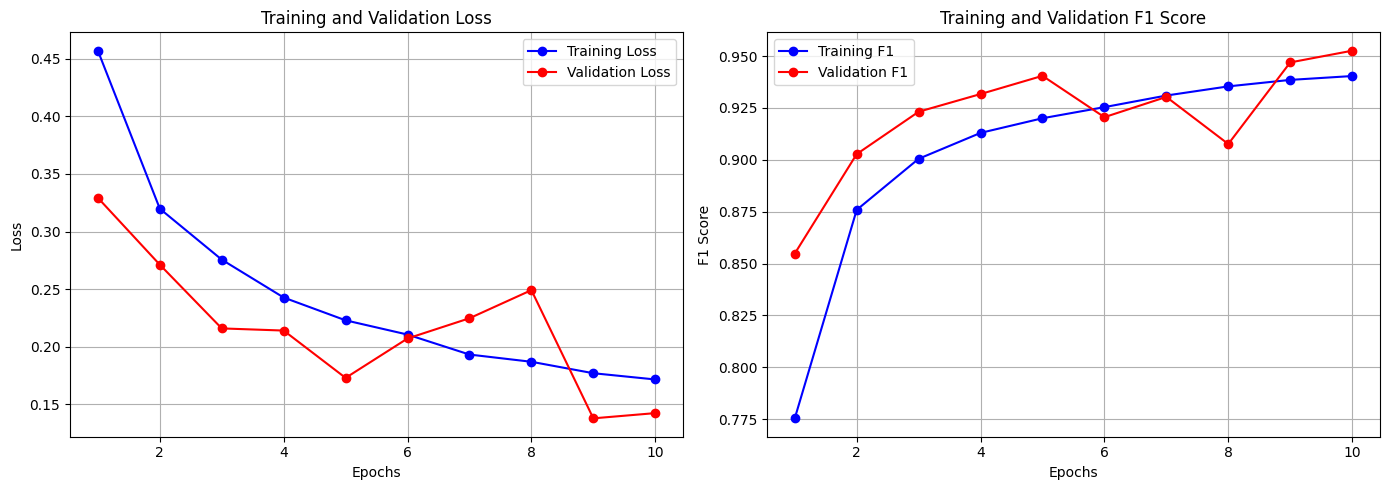

In [ ]:
import matplotlib.pyplot as plt

# Assuming NUM_EPOCHS is defined from hyperparameters
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(14, 5))

# Plot Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot F1 Score Curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_f1, 'b-o', label='Training F1')
plt.plot(epochs, val_f1, 'r-o', label='Validation F1')
plt.title('Training and Validation F1 Score')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# You can also plot accuracy similarly if desired:
# plt.figure(figsize=(7, 5))
# plt.plot(epochs, train_acc, 'g-o', label='Training Accuracy')
# plt.plot(epochs, val_acc, 'y-o', label='Validation Accuracy')
# plt.title('Training and Validation Accuracy')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np
from typing import Optional, Callable

def plot_val_confusion_matrix(model, loader, device, model_output_activation: Optional[Callable]):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs) # outputs are raw logits
            # Apply activation if specified, otherwise use raw outputs as probabilities
            pred_probs = model_output_activation(outputs) if model_output_activation is not None else outputs
            preds = (pred_probs > 0.5).float().cpu().numpy().flatten()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Person', 'Person'],
                yticklabels=['No Person', 'Person'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - Validation Set')
    plt.show()

# Execute the plotting function
plot_val_confusion_matrix(model, val_loader, device, model_output_activation)


In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from scipy.stats import gaussian_kde
from typing import Optional, Callable

def plot_score_distribution_continuous(model, loader, device, model_output_activation: Optional[Callable]):
    model.eval()
    scores_pos = []
    scores_neg = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            # Apply activation to convert outputs to probabilities if specified
            raw_outputs = model(inputs)
            outputs = model_output_activation(raw_outputs) if model_output_activation is not None else raw_outputs
            outputs = outputs.cpu().numpy().flatten()
            labels = labels.cpu().numpy().flatten()

            for score, label in zip(outputs, labels):
                if label == 1:
                    scores_pos.append(score)
                else:
                    scores_neg.append(score)

    plt.figure(figsize=(10, 6))
    x_range = np.linspace(0, 1, 500)

    # Generate KDE for 'No Person'
    if len(scores_neg) > 1:
        kde_neg = gaussian_kde(scores_neg, bw_method=0.1)
        y_neg = kde_neg(x_range)
        plt.plot(x_range, y_neg, color='blue', lw=2, label='True: No Person')
        plt.fill_between(x_range, 0, y_neg, color='blue', alpha=0.3)

    # Generate KDE for 'Person'
    if len(scores_pos) > 1:
        kde_pos = gaussian_kde(scores_pos, bw_method=0.1)
        y_pos = kde_pos(x_range)
        plt.plot(x_range, y_pos, color='red', lw=2, label='True: Person')
        plt.fill_between(x_range, 0, y_pos, color='red', alpha=0.3)

    # Scale set back to linear (default)
    plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold (0.5)')
    plt.xlabel('Model Output Score (Probability)')
    plt.ylabel('Density')
    plt.title('Continuous Score Distribution (KDE) by True Label')
    plt.legend(loc='upper center')
    plt.grid(axis='y', alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(bottom=0)
    plt.show()

# Plot the distribution
plot_score_distribution_continuous(model, val_loader, device, model_output_activation)


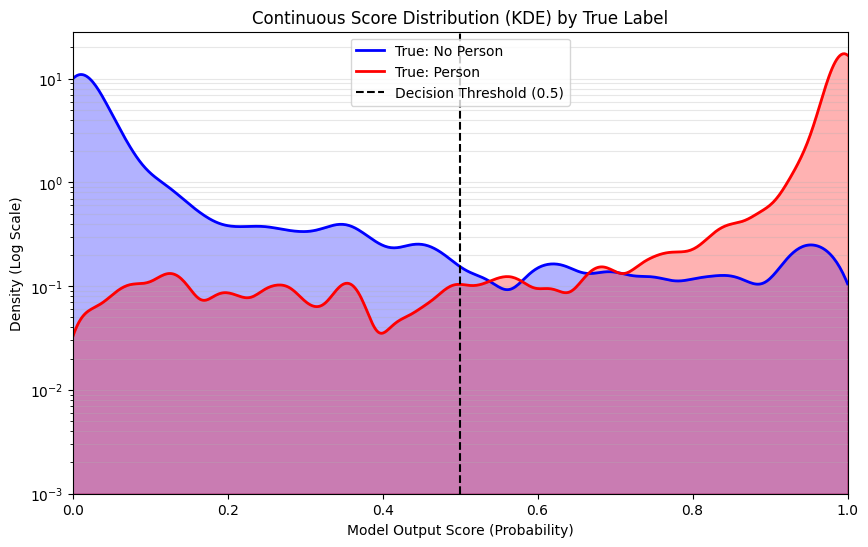

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from scipy.stats import gaussian_kde
from typing import Optional, Callable

def plot_score_distribution_continuous(model, loader, device, model_output_activation: Optional[Callable]):
    model.eval()
    scores_pos = []
    scores_neg = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            # Apply activation to convert outputs to probabilities if specified
            raw_outputs = model(inputs)
            outputs = model_output_activation(raw_outputs) if model_output_activation is not None else raw_outputs
            outputs = outputs.cpu().numpy().flatten()
            labels = labels.cpu().numpy().flatten()

            for score, label in zip(outputs, labels):
                if label == 1:
                    scores_pos.append(score)
                else:
                    scores_neg.append(score)

    plt.figure(figsize=(10, 6))
    x_range = np.linspace(0, 1, 500)

    # Generate KDE for 'No Person'
    if len(scores_neg) > 1:
        kde_neg = gaussian_kde(scores_neg, bw_method=0.1)
        y_neg = kde_neg(x_range)
        plt.plot(x_range, y_neg, color='blue', lw=2, label='True: No Person')
        plt.fill_between(x_range, 1e-3, y_neg, color='blue', alpha=0.3)

    # Generate KDE for 'Person'
    if len(scores_pos) > 1:
        kde_pos = gaussian_kde(scores_pos, bw_method=0.1)
        y_pos = kde_pos(x_range)
        plt.plot(x_range, y_pos, color='red', lw=2, label='True: Person')
        plt.fill_between(x_range, 1e-3, y_pos, color='red', alpha=0.3)

    plt.yscale('log')
    plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold (0.5)')
    plt.xlabel('Model Output Score (Probability)')
    plt.ylabel('Density (Log Scale)')
    plt.title('Continuous Score Distribution (KDE) by True Label')
    plt.legend(loc='upper center')
    plt.grid(axis='y', which='both', alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(bottom=1e-3) # Set floor for log scale visibility
    plt.show()

# Plot the distribution
plot_score_distribution_continuous(model, val_loader, device, model_output_activation)


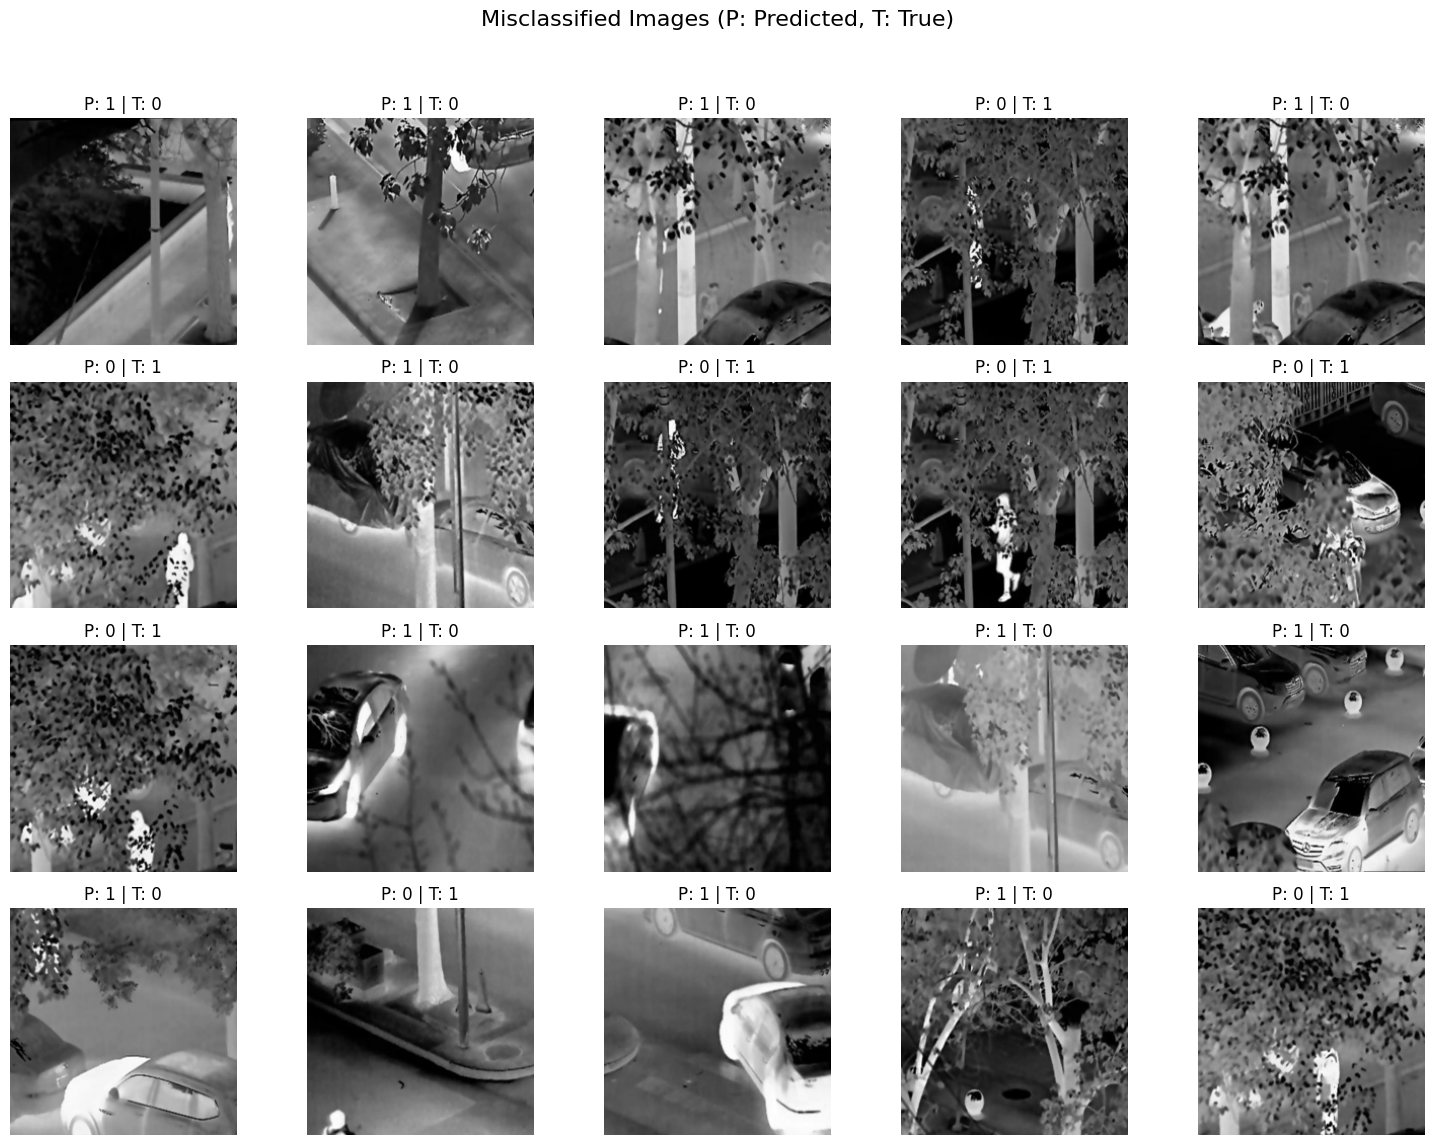

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_misclassified_images(model, loader, device, num_images=20):
    model.eval()
    misclassified = []

    # Iterate through validation set to find errors
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
            preds = (torch.sigmoid(outputs) > 0.5).float().cpu().view(-1)
            labels = labels.cpu().float()

            for i in range(len(preds)):
                if preds[i] != labels[i]:
                    # Store image, predicted label, and true label
                    misclassified.append((inputs[i].cpu(), preds[i].item(), labels[i].item()))

                if len(misclassified) >= num_images:
                    break
            if len(misclassified) >= num_images:
                break

    # Plotting the results
    plt.figure(figsize=(15, 12))
    for i in range(len(misclassified)):
        img, pred, true = misclassified[i]
        # Undo normalization for visualization (assuming mean=0.5, std=0.5)
        img = img * 0.5 + 0.5
        img = img.squeeze().numpy() # Remove channel dim for grayscale plot

        plt.subplot(4, 5, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"P: {int(pred)} | T: {int(true)}")
        plt.axis('off')

    plt.suptitle("Misclassified Images (P: Predicted, T: True)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the function
plot_misclassified_images(model, val_loader, device, num_images=20)